# Proyecto Integrador de Análisis de Datos con Python

## Análisis exploratorio del flujo vehicular en las unidades de peaje de la Red Vial Nacional del Perú, 2014–2025

**Alumno:** Johner Toledo  
**Fuente:** Plataforma Nacional de Datos Abiertos del Perú  
**Entidad:** Ministerio de Transportes y Comunicaciones del Perú  
**Dataset:** Flujo vehicular registrado en las unidades de peaje de la Red Vial Nacional 2014–2025 II Trimestre  
**Formato:** CSV

**Enlace de fuente:**  
https://www.datosabiertos.gob.pe/dataset/flujo-vehicular-registrado-en-las-unidades-de-peaje-de-la-red-vial-nacional-2014-%E2%80%93-2025-ii

## 1. Presentación del caso

El presente proyecto tiene como objetivo analizar el flujo vehicular registrado en las unidades de peaje de la Red Vial Nacional del Perú durante el periodo 2014–2025.

El dataset contiene información mensual sobre el tránsito de vehículos ligeros y pesados en diferentes peajes del país. A partir de esta información se busca identificar patrones de movilidad, evolución temporal del tránsito vehicular y diferencias entre departamentos, peajes y tipos de vehículos.

Este análisis puede ser útil para comprender el comportamiento de la demanda vial y apoyar decisiones relacionadas con infraestructura, transporte y planificación territorial.

## 2. Preparación del entorno

In [1]:
# Importación de librerías principales

import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

# Configuración de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


### 2.1 Carga del archivo CSV

> Coloca el archivo `Flujo vehicular registrado en peajes_2014-2025_II.csv` en la misma carpeta de este notebook.  
> Si estás ejecutando este notebook dentro de ChatGPT o Colab, ajusta la ruta del archivo según corresponda.

In [2]:
# Ruta del archivo CSV
archivo_csv = "Flujo vehicular registrado en peajes_2014-2025_II.csv"

# Ruta alternativa si se ejecuta desde un entorno donde el archivo está en /mnt/data
if not os.path.exists(archivo_csv):
    archivo_csv = "/mnt/data/Flujo vehicular registrado en peajes_2014-2025_II.csv"

# Carga del dataset
# Se usa latin1 porque el archivo contiene tildes y caracteres especiales.
df = pd.read_csv(archivo_csv, encoding="latin1")

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 10781
Columnas: 23


In [3]:
# Primeras filas del dataset
display(df.head(10))

,ID,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,NOMBRE_PEAJE,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
0,0,Concesionado,22PE5NACS1,San Martín,Aguas Claras,2099,"8,070.00",0,"2,586.00","2,374.00",720.00,315.00,"3,512.00",8.00,10169,328.00,9515,306.90,19684,635.00,2014,1,201401
1,1,Concesionado,04PE1SCAM1,Arequipa,Camaná,0,"24,644.00",0,"6,502.00","4,622.00","1,654.00","3,028.00","8,711.00",213.00,24644,795.00,24730,797.70,49374,"1,592.70",2014,1,201401
2,2,Concesionado,21PE3SCRO1,Puno,Caracoto,33643,"82,139.00",5797,"17,981.00","5,307.00","1,150.00","1,737.00","5,342.00",12.00,115782,"3,734.90",37326,"1,204.10",153108,"4,939.00",2014,1,201401
3,3,Concesionado,12PE3NCRA1,Junín,Casaracra-Concesión,10,"46,944.00",0,"16,981.00","18,585.00","4,463.00","3,058.00","19,400.00",135.00,46954,"1,514.60",62622,"2,020.10",109576,"3,534.70",2014,1,201401
4,4,Concesionado,08PE3SCSC1,Cusco,Ccasacancha (Huillque),0,"23,831.00",0,"4,709.00","3,941.00",447.00,769.00,"3,945.00",95.00,23831,768.70,13906,448.60,37737,"1,217.30",2014,1,201401
5,5,Concesionado,13PE1NCMA1,La Libertad,Chicama,298,"55,877.00",9834,"14,375.00","14,727.00","3,437.00","3,638.00","18,623.00",155.00,56175,"1,812.10",64789,"2,090.00",120964,"3,902.10",2014,1,201401
6,6,Concesionado,15PE1SCLA1,Lima,Chilca,0,"252,757.00",0,"29,157.00","19,799.00","3,766.00","6,563.00","24,456.00",433.00,252757,"8,153.50",84174,"2,715.30",336931,"10,868.70",2014,1,201401
7,7,Concesionado,20PE1NJCLS1,Piura,Chulucanas,1958,"33,423.00",301,"10,492.00","4,906.00",185.00,530.00,"4,364.00",179.00,35381,"1,141.30",20957,676.00,56338,"1,817.40",2014,1,201401
8,8,Concesionado,13PE08CDS1,La Libertad,Ciudad de Dios,0,0.00,0,0.00,0.00,0.00,0.00,0.00,0.00,0,0.00,0,0.00,0,0.00,2014,1,201401
9,9,Concesionado,15PE22CCA1,Lima,Corcona-Concesión,5045,"80,704.00",829,"25,184.00","27,487.00","6,485.00","4,326.00","29,582.00",540.00,85749,"2,766.10",94433,"3,046.20",180182,"5,812.30",2014,1,201401


In [4]:
# Nombres de columnas
display(pd.DataFrame({"columnas": df.columns}))

,columnas
0,ID
1,ADMINIST
2,CODIGO_PEAJE
3,DEPARTAMENTO
4,NOMBRE_PEAJE
5,VEH_LIGEROS_TAR_DIF
6,VEH_LIGEROS_AUTOMOVILES
7,VEH_PESADOS_TAR_DIF
8,VEH_PESADOS__2E
9,VEH_PESADOS_3E


In [5]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10781 non-null  int64  
 1   ADMINIST                 10781 non-null  str    
 2   CODIGO_PEAJE             10781 non-null  str    
 3   DEPARTAMENTO             10781 non-null  str    
 4   NOMBRE_PEAJE             10781 non-null  str    
 5   VEH_LIGEROS_TAR_DIF      10781 non-null  int64  
 6   VEH_LIGEROS_AUTOMOVILES  10768 non-null  float64
 7   VEH_PESADOS_TAR_DIF      10781 non-null  int64  
 8   VEH_PESADOS__2E          10773 non-null  float64
 9   VEH_PESADOS_3E           10773 non-null  float64
 10  VEH_PESADOS_4E           10773 non-null  float64
 11  VEH_PESADOS_5E           10773 non-null  float64
 12  VEH_PESADOS_6E           10773 non-null  float64
 13  VEH_PESADOS_7E           10773 non-null  float64
 14  VEH_LIGEROS_TOTAL        10781 no

In [6]:
# Estadísticas descriptivas iniciales
display(df.describe())

,ID,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS_TAR_DIF,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO
count,"10,781.00","10,781.00","10,768.00","10,781.00","10,773.00","10,773.00","10,773.00","10,773.00","10,773.00","10,773.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00","10,781.00"
mean,"5,390.00","1,896.09","44,374.21",817.15,"8,630.37","7,666.94","1,943.49","2,289.99","11,708.79",162.75,"46,216.79","1,521.11","33,195.43","1,092.22","79,412.23","2,613.36","2,019.34",6.37,"201,940.29"
std,"3,112.35","6,297.01","66,000.78","2,710.77","10,942.91","9,845.50","2,608.11","3,324.18","16,266.68",391.49,"67,003.82","2,206.05","41,535.15","1,364.47","99,045.96","3,258.06",3.32,3.45,331.86
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"2,014.00",1.00,"201,401.00"
25%,"2,695.00",0.00,"11,284.00",0.00,"2,125.00","1,300.00",309.00,269.00,"1,728.00",12.00,"11,870.00",393.60,"7,393.00",244.20,"22,414.00",739.00,"2,016.00",3.00,"201,612.00"
50%,"5,390.00",0.00,"23,460.50",0.00,"4,218.00","3,573.00",807.00,808.00,"4,172.00",46.00,"24,623.00",811.10,"15,964.00",524.10,"42,083.00","1,390.20","2,019.00",6.00,"201,911.00"
75%,"8,085.00",376.00,"47,658.25",0.00,"10,589.00","8,678.00","2,486.00","2,817.00","15,900.00",192.00,"50,025.00","1,644.20","40,611.00","1,335.70","99,407.00","3,282.10","2,022.00",9.00,"202,209.00"
max,"10,780.00","71,734.00","796,486.00","38,818.00","73,590.00","78,943.00","25,137.00","25,361.00","99,895.00","21,799.00","796,486.00","27,914.10","241,058.00","8,440.80","1,037,544.00","35,023.40","2,025.00",12.00,"202,506.00"


### Interpretación inicial

El dataset se cargó correctamente y contiene registros mensuales del flujo vehicular en peajes del Perú. La base incluye variables de identificación del peaje, ubicación, administración, año, mes y cantidades de vehículos ligeros y pesados.

## 3. Diccionario de datos

In [7]:
# Diccionario de datos resumido

diccionario = pd.DataFrame({
    "Variable": [
        "ID", "ADMINIST", "CODIGO_PEAJE", "DEPARTAMENTO", "NOMBRE_PEAJE",
        "VEH_LIGEROS_TAR_DIF", "VEH_LIGEROS_AUTOMOVILES", "VEH_PESADOS_TAR_DIF",
        "VEH_PESADOS__2E", "VEH_PESADOS_3E", "VEH_PESADOS_4E", "VEH_PESADOS_5E",
        "VEH_PESADOS_6E", "VEH_PESADOS_7E", "VEH_LIGEROS_TOTAL", "VEH_LIGEROS_IMD",
        "VEH_PESADOS_TOTAL", "VEH_PESADOS_IMD", "VEH_TOTAL", "VEH_IMD",
        "ANIO", "MES", "PERIODO"
    ],
    "Descripción": [
        "Identificador del registro",
        "Tipo de administración del peaje",
        "Código de la unidad de peaje",
        "Departamento donde se ubica el peaje",
        "Nombre de la unidad de peaje",
        "Vehículos ligeros con tarifa diferenciada",
        "Vehículos ligeros tipo automóvil",
        "Vehículos pesados con tarifa diferenciada",
        "Vehículos pesados de 2 ejes",
        "Vehículos pesados de 3 ejes",
        "Vehículos pesados de 4 ejes",
        "Vehículos pesados de 5 ejes",
        "Vehículos pesados de 6 ejes",
        "Vehículos pesados de 7 ejes",
        "Total de vehículos ligeros",
        "Índice medio diario de vehículos ligeros",
        "Total de vehículos pesados",
        "Índice medio diario de vehículos pesados",
        "Total de vehículos registrados",
        "Índice medio diario total",
        "Año de registro",
        "Mes de registro",
        "Periodo en formato año-mes"
    ],
    "Tipo esperado": [
        "Numérico", "Categórico", "Categórico", "Categórico", "Categórico",
        "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
        "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
        "Numérico", "Numérico", "Numérico", "Numérico"
    ]
})

display(diccionario)

,Variable,Descripción,Tipo esperado
0,ID,Identificador del registro,Numérico
1,ADMINIST,Tipo de administración del peaje,Categórico
2,CODIGO_PEAJE,Código de la unidad de peaje,Categórico
3,DEPARTAMENTO,Departamento donde se ubica el peaje,Categórico
4,NOMBRE_PEAJE,Nombre de la unidad de peaje,Categórico
5,VEH_LIGEROS_TAR_DIF,Vehículos ligeros con tarifa diferenciada,Numérico
6,VEH_LIGEROS_AUTOMOVILES,Vehículos ligeros tipo automóvil,Numérico
7,VEH_PESADOS_TAR_DIF,Vehículos pesados con tarifa diferenciada,Numérico
8,VEH_PESADOS__2E,Vehículos pesados de 2 ejes,Numérico
9,VEH_PESADOS_3E,Vehículos pesados de 3 ejes,Numérico


## 4. Limpieza y transformación de datos con Pandas

In [8]:
# Copia de trabajo para preservar el dataset original

df_limpio = df.copy()

In [9]:
# Revisión de valores nulos

nulos = df_limpio.isnull().sum().sort_values(ascending=False)
display(nulos[nulos > 0])

VEH_LIGEROS_AUTOMOVILES    13
VEH_PESADOS_6E              8
VEH_PESADOS_7E              8
VEH_PESADOS_5E              8
VEH_PESADOS_4E              8
VEH_PESADOS_3E              8
VEH_PESADOS__2E             8
dtype: int64

In [10]:
# Tratamiento de valores nulos
# Los nulos aparecen en columnas de conteo vehicular. Se reemplazan por 0 porque representan ausencia de registro en esa categoría.

columnas_numericas_con_nulos = [
    "VEH_LIGEROS_AUTOMOVILES",
    "VEH_PESADOS__2E",
    "VEH_PESADOS_3E",
    "VEH_PESADOS_4E",
    "VEH_PESADOS_5E",
    "VEH_PESADOS_6E",
    "VEH_PESADOS_7E"
]

for col in columnas_numericas_con_nulos:
    df_limpio[col] = df_limpio[col].fillna(0)

print("Valores nulos después del tratamiento:")
display(df_limpio.isnull().sum()[df_limpio.isnull().sum() > 0])

Valores nulos después del tratamiento:


Series([], dtype: int64)

In [11]:
# Verificación de duplicados

duplicados = df_limpio.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicados}")

Cantidad de filas duplicadas: 0


In [12]:
# Eliminación de duplicados si existieran

df_limpio = df_limpio.drop_duplicates()
print(f"Filas después de eliminar duplicados: {df_limpio.shape[0]}")

Filas después de eliminar duplicados: 10781


In [13]:
# Corrección de texto en departamentos
# Se unifica Apurimac con Apurímac.

df_limpio["DEPARTAMENTO"] = df_limpio["DEPARTAMENTO"].replace({
    "Apurimac": "Apurímac"
})

print("Departamentos registrados después de la limpieza:")
display(sorted(df_limpio["DEPARTAMENTO"].unique()))

Departamentos registrados después de la limpieza:


['Amazonas',
 'Apurímac',
 'Arequipa',
 'Ayacucho',
 'Cajamarca',
 'Cusco',
 'Huánuco',
 'Ica',
 'Junín',
 'La Libertad',
 'Lambayeque',
 'Lima',
 'Madre de Dios',
 'Moquegua',
 'Piura',
 'Puno',
 'San Martin',
 'San Martín',
 'Tacna',
 'Tumbes',
 'Áncash']

In [14]:
# Creación de columna fecha

df_limpio["FECHA"] = pd.to_datetime(
    df_limpio["ANIO"].astype(str) + "-" + df_limpio["MES"].astype(str).str.zfill(2) + "-01"
)

# Creación de nombres de mes en español
meses = {
    1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
    5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
    9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"
}

df_limpio["MES_NOMBRE"] = df_limpio["MES"].map(meses)

# Variables nuevas para análisis
df_limpio["PARTICIPACION_LIGEROS_%"] = (df_limpio["VEH_LIGEROS_TOTAL"] / df_limpio["VEH_TOTAL"]) * 100
df_limpio["PARTICIPACION_PESADOS_%"] = (df_limpio["VEH_PESADOS_TOTAL"] / df_limpio["VEH_TOTAL"]) * 100

# Evitar posibles infinitos si hubiera división entre cero
df_limpio = df_limpio.replace([np.inf, -np.inf], np.nan)

display(df_limpio[["ANIO", "MES", "FECHA", "MES_NOMBRE", "VEH_TOTAL", "PARTICIPACION_LIGEROS_%", "PARTICIPACION_PESADOS_%"]].head())

,ANIO,MES,FECHA,MES_NOMBRE,VEH_TOTAL,PARTICIPACION_LIGEROS_%,PARTICIPACION_PESADOS_%
0,2014,1,2014-01-01,Enero,19684,51.66,48.34
1,2014,1,2014-01-01,Enero,49374,49.91,50.09
2,2014,1,2014-01-01,Enero,153108,75.62,24.38
3,2014,1,2014-01-01,Enero,109576,42.85,57.15
4,2014,1,2014-01-01,Enero,37737,63.15,36.85


In [15]:
# Verificación final de tipos de datos

display(df_limpio.dtypes)

ID                                  int64
ADMINIST                              str
CODIGO_PEAJE                          str
DEPARTAMENTO                          str
NOMBRE_PEAJE                          str
VEH_LIGEROS_TAR_DIF                 int64
VEH_LIGEROS_AUTOMOVILES           float64
VEH_PESADOS_TAR_DIF                 int64
VEH_PESADOS__2E                   float64
VEH_PESADOS_3E                    float64
VEH_PESADOS_4E                    float64
VEH_PESADOS_5E                    float64
VEH_PESADOS_6E                    float64
VEH_PESADOS_7E                    float64
VEH_LIGEROS_TOTAL                   int64
VEH_LIGEROS_IMD                   float64
VEH_PESADOS_TOTAL                   int64
VEH_PESADOS_IMD                   float64
VEH_TOTAL                           int64
VEH_IMD                           float64
ANIO                                int64
MES                                 int64
PERIODO                             int64
FECHA                      datetim

### Interpretación de limpieza

Se trataron valores nulos en columnas numéricas de conteo vehicular, se verificó la existencia de duplicados y se corrigió la escritura del departamento Apurímac. Además, se creó una columna de fecha y variables porcentuales para comparar la participación de vehículos ligeros y pesados.

## 5. Análisis Exploratorio de Datos - EDA

In [16]:
# Resumen general del dataset limpio

resumen_general = pd.DataFrame({
    "Indicador": [
        "Total de registros",
        "Cantidad de departamentos",
        "Cantidad de unidades de peaje",
        "Año inicial",
        "Año final",
        "Flujo vehicular total"
    ],
    "Valor": [
        df_limpio.shape[0],
        df_limpio["DEPARTAMENTO"].nunique(),
        df_limpio["NOMBRE_PEAJE"].nunique(),
        df_limpio["ANIO"].min(),
        df_limpio["ANIO"].max(),
        df_limpio["VEH_TOTAL"].sum()
    ]
})

display(resumen_general)

,Indicador,Valor
0,Total de registros,10781
1,Cantidad de departamentos,21
2,Cantidad de unidades de peaje,82
3,Año inicial,2014
4,Año final,2025
5,Flujo vehicular total,856143222


In [17]:
# Flujo vehicular por año

flujo_anual = df_limpio.groupby("ANIO", as_index=False).agg({
    "VEH_TOTAL": "sum",
    "VEH_LIGEROS_TOTAL": "sum",
    "VEH_PESADOS_TOTAL": "sum"
})

display(flujo_anual)

,ANIO,VEH_TOTAL,VEH_LIGEROS_TOTAL,VEH_PESADOS_TOTAL
0,2014,56067153,29888369,26178784
1,2015,59930432,32833469,27096963
2,2016,65965405,36674005,29291400
3,2017,62324216,34722632,27601584
4,2018,70499860,39231536,31268324
5,2019,80141386,45193722,34947664
6,2020,57432290,33515703,23916587
7,2021,93040557,57877281,35163276
8,2022,93900542,57763500,36137042
9,2023,81308464,49069671,32238793


In [18]:
# Top 10 departamentos con mayor flujo vehicular

top_departamentos = (
    df_limpio.groupby("DEPARTAMENTO", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
    .head(10)
)

display(top_departamentos)

,DEPARTAMENTO,VEH_TOTAL
11,Lima,238057008
9,La Libertad,104069687
7,Ica,84193076
2,Arequipa,83506916
14,Piura,77784144
15,Puno,49607680
20,Áncash,44521171
8,Junín,43602354
10,Lambayeque,31326111
5,Cusco,16557053


In [19]:
# Top 10 unidades de peaje con mayor flujo vehicular

top_peajes = (
    df_limpio.groupby("NOMBRE_PEAJE", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
    .head(10)
)

display(top_peajes)

,NOMBRE_PEAJE,VEH_TOTAL
13,Chilca,65408390
78,Variante de Pasamayo,46881491
23,El Paraíso,42974326
30,Jahuay Chincha,35090338
12,Chicama,34857817
51,Piura Sullana,31123826
80,Virú,30921368
75,Uchumayo-Concesión,30627112
16,Corcona-Concesión,28827571
27,Ica,28006838


In [20]:
# Participación total de vehículos ligeros y pesados

participacion_tipo = pd.DataFrame({
    "Tipo de vehículo": ["Ligeros", "Pesados"],
    "Total": [
        df_limpio["VEH_LIGEROS_TOTAL"].sum(),
        df_limpio["VEH_PESADOS_TOTAL"].sum()
    ]
})

participacion_tipo["Participación_%"] = participacion_tipo["Total"] / participacion_tipo["Total"].sum() * 100

display(participacion_tipo)

,Tipo de vehículo,Total,Participación_%
0,Ligeros,498263245,58.20
1,Pesados,357879977,41.80


In [21]:
# Flujo promedio mensual

flujo_mensual = (
    df_limpio.groupby(["MES", "MES_NOMBRE"], as_index=False)["VEH_TOTAL"]
    .mean()
    .sort_values("MES")
)

display(flujo_mensual)

,MES,MES_NOMBRE,VEH_TOTAL
0,1,Enero,"88,254.78"
1,2,Febrero,"82,683.97"
2,3,Marzo,"77,996.58"
3,4,Abril,"69,718.35"
4,5,Mayo,"73,895.45"
5,6,Junio,"71,758.45"
6,7,Julio,"80,677.41"
7,8,Agosto,"82,287.42"
8,9,Septiembre,"76,601.32"
9,10,Octubre,"81,810.62"


### Interpretación del EDA

El análisis exploratorio permite observar la evolución del flujo vehicular a lo largo del tiempo, identificar los departamentos y peajes con mayor tránsito, y comparar la participación de vehículos ligeros y pesados. Estas variables permiten desarrollar análisis univariados y multivariados.

## 6. Visualización de datos con Matplotlib

A continuación se generan 5 gráficos personalizados con Matplotlib. Las imágenes se guardan automáticamente en la carpeta `figuras_exportadas`.

In [22]:
# Carpeta para exportar gráficos

carpeta_figuras = "figuras_exportadas"
os.makedirs(carpeta_figuras, exist_ok=True)

print(f"Carpeta creada o verificada: {carpeta_figuras}")

Carpeta creada o verificada: figuras_exportadas


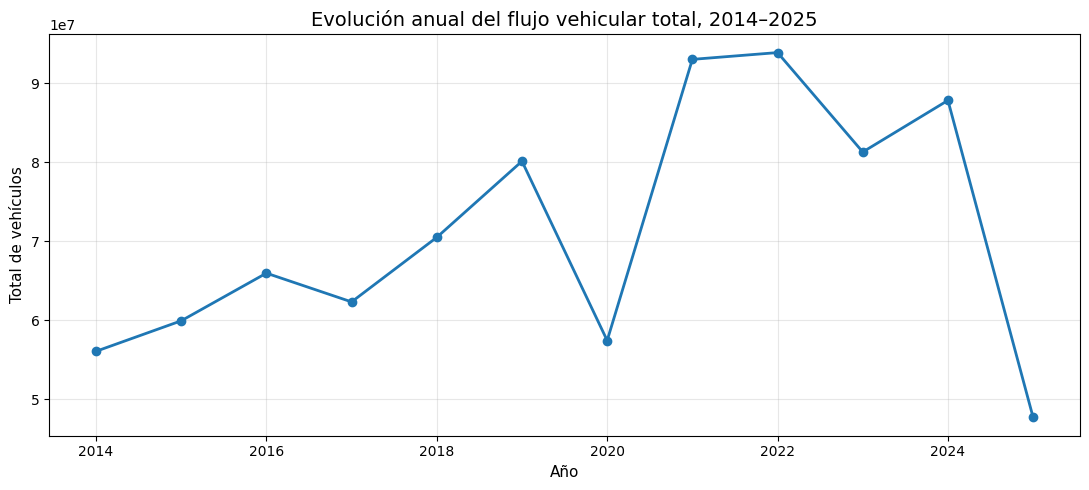

In [23]:
# Gráfico 1 - Matplotlib: Evolución anual del flujo vehicular total

plt.figure(figsize=(11, 5))
plt.plot(flujo_anual["ANIO"], flujo_anual["VEH_TOTAL"], marker="o", linewidth=2)
plt.title("Evolución anual del flujo vehicular total, 2014–2025")
plt.xlabel("Año")
plt.ylabel("Total de vehículos")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/matplotlib_01_evolucion_anual.png", dpi=300)
plt.show()

**Interpretación:** El gráfico permite observar la tendencia anual del flujo vehicular total registrado en los peajes de la Red Vial Nacional.

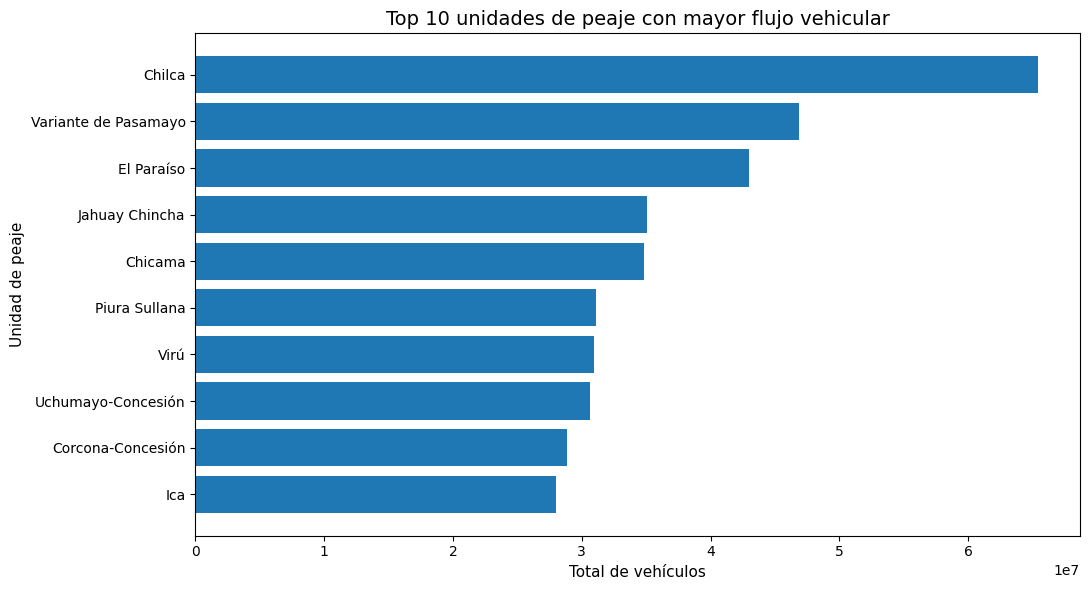

In [24]:
# Gráfico 2 - Matplotlib: Top 10 peajes con mayor flujo vehicular

plt.figure(figsize=(11, 6))
plt.barh(top_peajes["NOMBRE_PEAJE"], top_peajes["VEH_TOTAL"])
plt.title("Top 10 unidades de peaje con mayor flujo vehicular")
plt.xlabel("Total de vehículos")
plt.ylabel("Unidad de peaje")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/matplotlib_02_top_peajes.png", dpi=300)
plt.show()

**Interpretación:** Se identifican las unidades de peaje que concentran el mayor volumen de tránsito vehicular durante el periodo analizado.

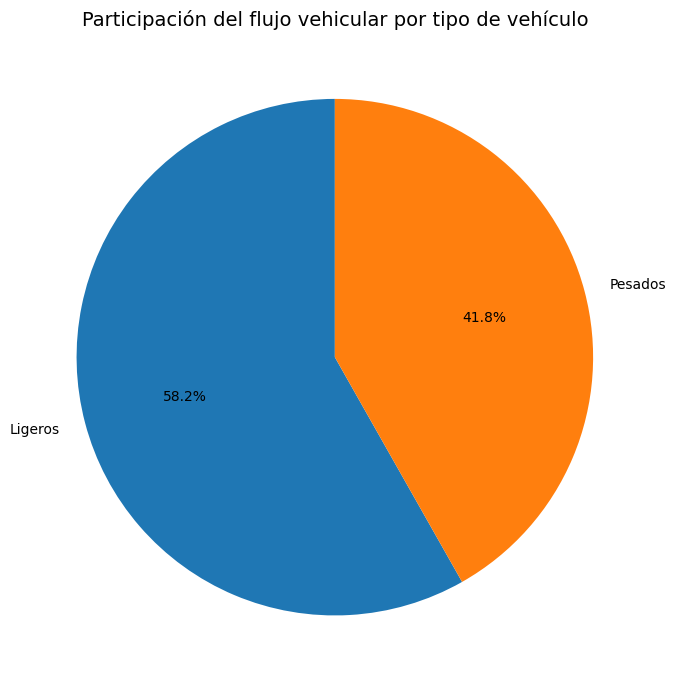

In [25]:
# Gráfico 3 - Matplotlib: Participación de vehículos ligeros y pesados

plt.figure(figsize=(7, 7))
plt.pie(
    participacion_tipo["Total"],
    labels=participacion_tipo["Tipo de vehículo"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Participación del flujo vehicular por tipo de vehículo")
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/matplotlib_03_participacion_tipo.png", dpi=300)
plt.show()

**Interpretación:** El gráfico muestra la proporción del flujo vehicular correspondiente a vehículos ligeros y pesados.

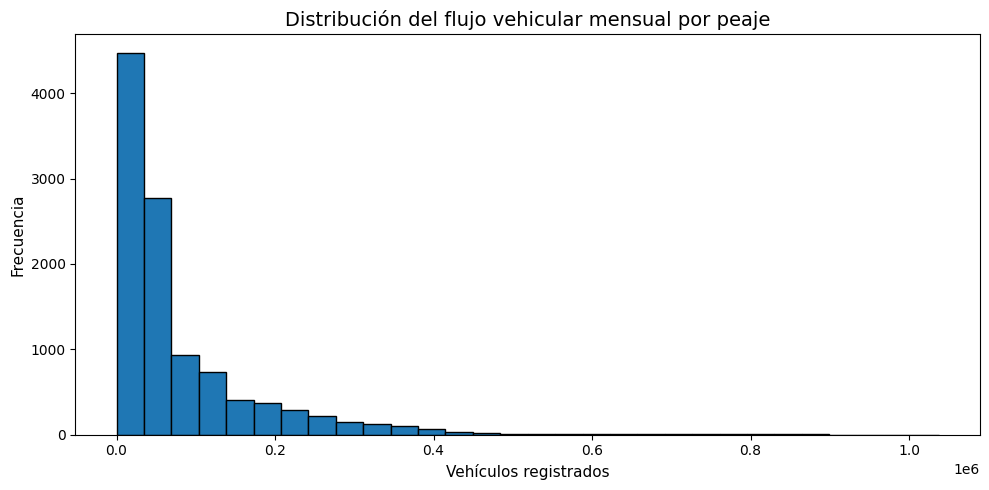

In [26]:
# Gráfico 4 - Matplotlib: Histograma del flujo vehicular mensual

plt.figure(figsize=(10, 5))
plt.hist(df_limpio["VEH_TOTAL"], bins=30, edgecolor="black")
plt.title("Distribución del flujo vehicular mensual por peaje")
plt.xlabel("Vehículos registrados")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/matplotlib_04_histograma_flujo.png", dpi=300)
plt.show()

**Interpretación:** La distribución permite identificar si la mayoría de registros mensuales se concentran en valores bajos, medios o altos de tránsito vehicular.

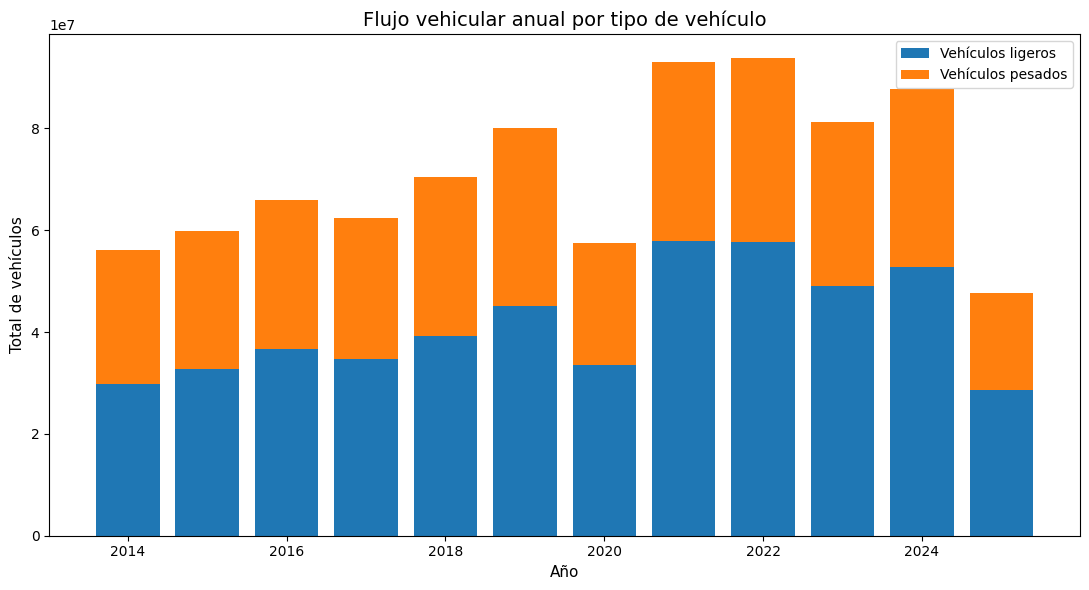

In [27]:
# Gráfico 5 - Matplotlib: Barras apiladas de vehículos ligeros y pesados por año

plt.figure(figsize=(11, 6))
plt.bar(flujo_anual["ANIO"], flujo_anual["VEH_LIGEROS_TOTAL"], label="Vehículos ligeros")
plt.bar(
    flujo_anual["ANIO"],
    flujo_anual["VEH_PESADOS_TOTAL"],
    bottom=flujo_anual["VEH_LIGEROS_TOTAL"],
    label="Vehículos pesados"
)
plt.title("Flujo vehicular anual por tipo de vehículo")
plt.xlabel("Año")
plt.ylabel("Total de vehículos")
plt.legend()
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/matplotlib_05_barras_apiladas.png", dpi=300)
plt.show()

**Interpretación:** El gráfico compara la composición anual del flujo vehicular entre vehículos ligeros y pesados.

## 7. Visualización de datos con Seaborn

A continuación se generan 5 gráficos personalizados con Seaborn.

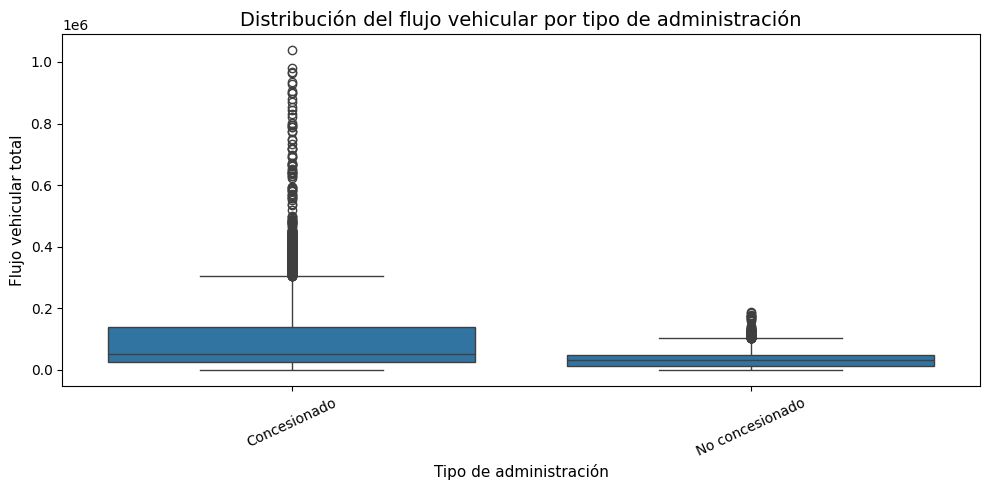

In [28]:
# Gráfico 1 - Seaborn: Boxplot del flujo vehicular por tipo de administración

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_limpio, x="ADMINIST", y="VEH_TOTAL")
plt.title("Distribución del flujo vehicular por tipo de administración")
plt.xlabel("Tipo de administración")
plt.ylabel("Flujo vehicular total")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/seaborn_01_boxplot_administracion.png", dpi=300)
plt.show()

**Interpretación:** El boxplot permite comparar la variabilidad del flujo vehicular según el tipo de administración del peaje.

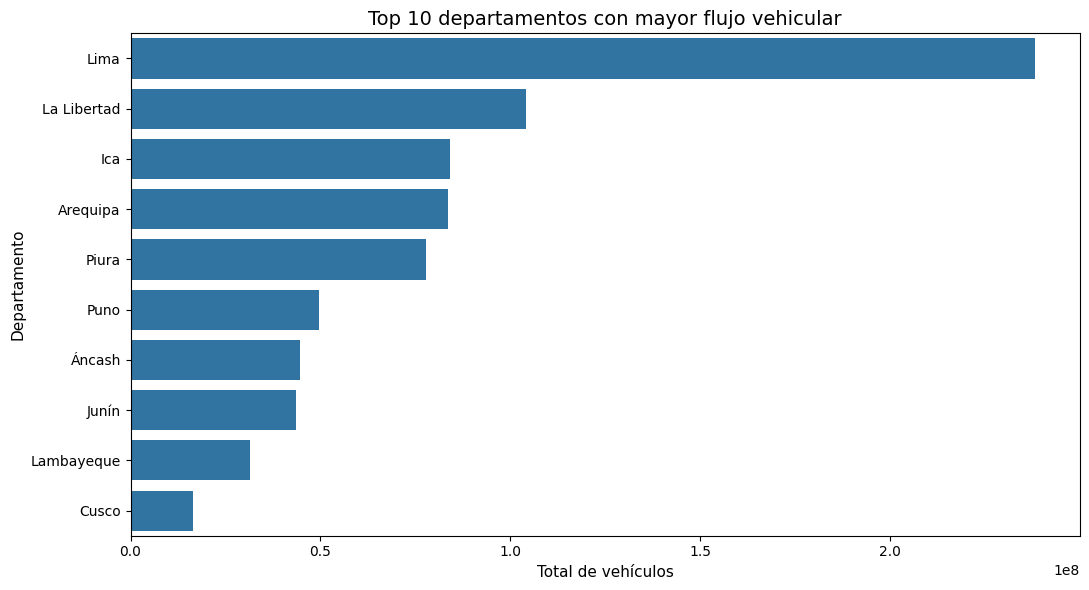

In [29]:
# Gráfico 2 - Seaborn: Barplot de top 10 departamentos

plt.figure(figsize=(11, 6))
sns.barplot(data=top_departamentos, x="VEH_TOTAL", y="DEPARTAMENTO")
plt.title("Top 10 departamentos con mayor flujo vehicular")
plt.xlabel("Total de vehículos")
plt.ylabel("Departamento")
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/seaborn_02_top_departamentos.png", dpi=300)
plt.show()

**Interpretación:** Se muestran los departamentos que concentran mayor tránsito vehicular registrado en peajes.

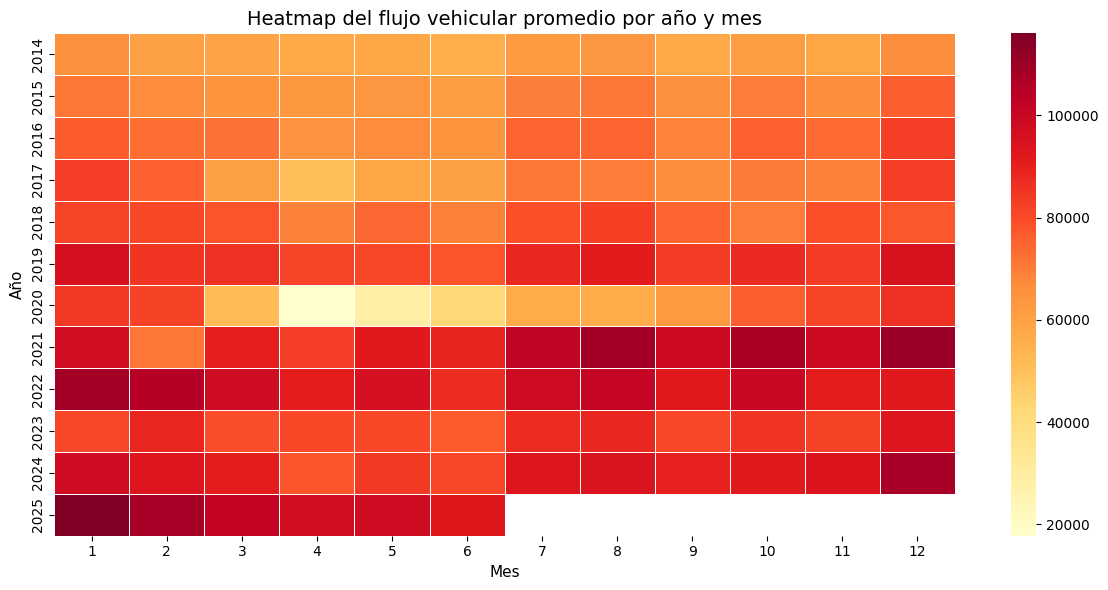

In [30]:
# Gráfico 3 - Seaborn: Heatmap de flujo vehicular promedio por año y mes

matriz_anio_mes = df_limpio.pivot_table(
    index="ANIO",
    columns="MES",
    values="VEH_TOTAL",
    aggfunc="mean"
)

plt.figure(figsize=(12, 6))
sns.heatmap(matriz_anio_mes, cmap="YlOrRd", linewidths=0.5)
plt.title("Heatmap del flujo vehicular promedio por año y mes")
plt.xlabel("Mes")
plt.ylabel("Año")
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/seaborn_03_heatmap_anio_mes.png", dpi=300)
plt.show()

**Interpretación:** El mapa de calor permite observar patrones temporales y posibles meses con mayor o menor flujo vehicular promedio.

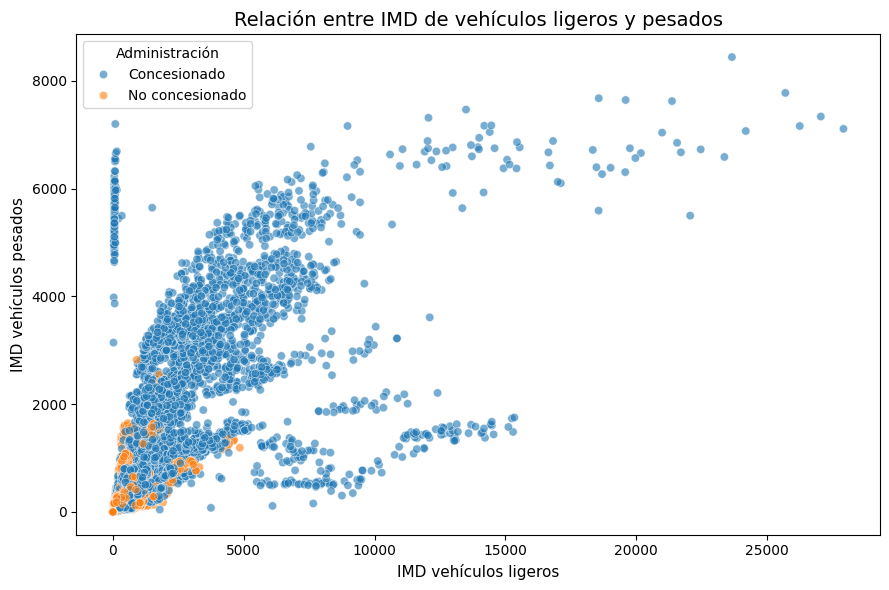

In [31]:
# Gráfico 4 - Seaborn: Scatterplot entre IMD de ligeros y pesados

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_limpio,
    x="VEH_LIGEROS_IMD",
    y="VEH_PESADOS_IMD",
    hue="ADMINIST",
    alpha=0.6
)
plt.title("Relación entre IMD de vehículos ligeros y pesados")
plt.xlabel("IMD vehículos ligeros")
plt.ylabel("IMD vehículos pesados")
plt.legend(title="Administración")
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/seaborn_04_scatter_imd.png", dpi=300)
plt.show()

**Interpretación:** El gráfico permite analizar la relación entre el tránsito medio diario de vehículos ligeros y pesados.

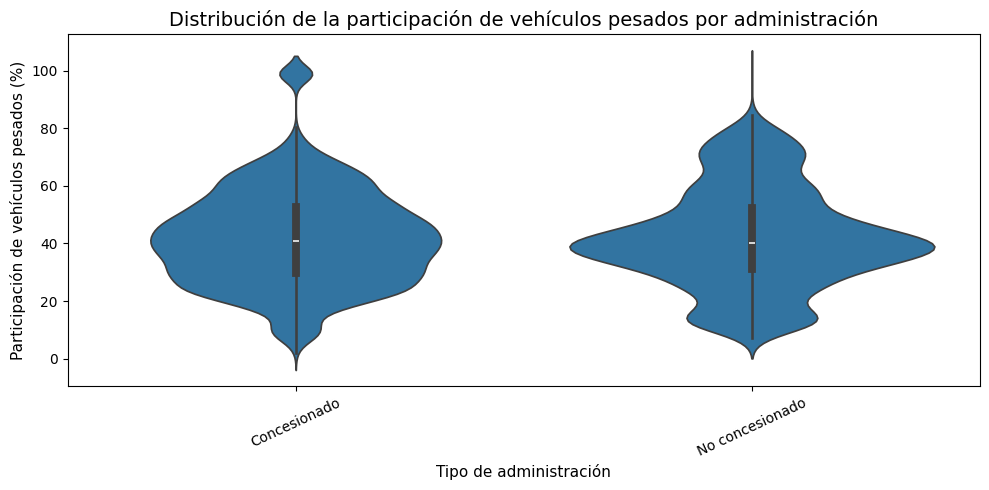

In [32]:
# Gráfico 5 - Seaborn: Violinplot de participación de vehículos pesados por administración

plt.figure(figsize=(10, 5))
sns.violinplot(data=df_limpio, x="ADMINIST", y="PARTICIPACION_PESADOS_%")
plt.title("Distribución de la participación de vehículos pesados por administración")
plt.xlabel("Tipo de administración")
plt.ylabel("Participación de vehículos pesados (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(f"{carpeta_figuras}/seaborn_05_violin_pesados.png", dpi=300)
plt.show()

**Interpretación:** El violinplot muestra la variabilidad de la participación porcentual de vehículos pesados según el tipo de administración.

## 8. Visualización de datos con Plotly

A continuación se generan 3 gráficos interactivos con Plotly. Cada gráfico se exporta en formato HTML dentro de la carpeta `figuras_exportadas`.

In [33]:
# Gráfico 1 - Plotly: Evolución mensual interactiva del flujo vehicular total

flujo_fecha = df_limpio.groupby("FECHA", as_index=False)["VEH_TOTAL"].sum()

fig1 = px.line(
    flujo_fecha,
    x="FECHA",
    y="VEH_TOTAL",
    title="Evolución mensual del flujo vehicular total",
    markers=True,
    labels={"FECHA": "Fecha", "VEH_TOTAL": "Total de vehículos"}
)

fig1.write_html(f"{carpeta_figuras}/plotly_01_evolucion_mensual.html")
fig1.show()

**Interpretación:** El gráfico interactivo permite explorar la evolución mensual del flujo vehicular durante el periodo 2014–2025.

In [34]:
# Gráfico 2 - Plotly: Ranking interactivo de peajes

top_15_peajes = (
    df_limpio.groupby("NOMBRE_PEAJE", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
    .head(15)
)

fig2 = px.bar(
    top_15_peajes,
    x="VEH_TOTAL",
    y="NOMBRE_PEAJE",
    orientation="h",
    title="Top 15 unidades de peaje con mayor flujo vehicular",
    labels={"VEH_TOTAL": "Total de vehículos", "NOMBRE_PEAJE": "Unidad de peaje"}
)

fig2.update_layout(yaxis={"categoryorder": "total ascending"})
fig2.write_html(f"{carpeta_figuras}/plotly_02_top_peajes.html")
fig2.show()

**Interpretación:** El gráfico permite identificar de forma interactiva los peajes con mayor volumen de vehículos registrados.

In [35]:
# Gráfico 3 - Plotly: Treemap por departamento y peaje

flujo_departamento_peaje = (
    df_limpio.groupby(["DEPARTAMENTO", "NOMBRE_PEAJE"], as_index=False)["VEH_TOTAL"]
    .sum()
)

fig3 = px.treemap(
    flujo_departamento_peaje,
    path=["DEPARTAMENTO", "NOMBRE_PEAJE"],
    values="VEH_TOTAL",
    title="Composición del flujo vehicular por departamento y peaje"
)

fig3.write_html(f"{carpeta_figuras}/plotly_03_treemap_departamento_peaje.html")
fig3.show()

**Interpretación:** El treemap permite visualizar la concentración del flujo vehicular según departamento y unidad de peaje.

## 9. Hallazgos principales

In [36]:
# Cálculo de principales hallazgos automáticos

anio_mayor_flujo = flujo_anual.loc[flujo_anual["VEH_TOTAL"].idxmax()]
departamento_mayor_flujo = top_departamentos.iloc[0]
peaje_mayor_flujo = top_peajes.iloc[0]
tipo_mayor_participacion = participacion_tipo.sort_values("Total", ascending=False).iloc[0]

print("Hallazgos principales:")
print(f"1. El año con mayor flujo vehicular fue {int(anio_mayor_flujo['ANIO'])}, con {anio_mayor_flujo['VEH_TOTAL']:,.0f} vehículos registrados.")
print(f"2. El departamento con mayor flujo vehicular fue {departamento_mayor_flujo['DEPARTAMENTO']}, con {departamento_mayor_flujo['VEH_TOTAL']:,.0f} vehículos.")
print(f"3. La unidad de peaje con mayor flujo fue {peaje_mayor_flujo['NOMBRE_PEAJE']}, con {peaje_mayor_flujo['VEH_TOTAL']:,.0f} vehículos.")
print(f"4. El tipo de vehículo con mayor participación fue {tipo_mayor_participacion['Tipo de vehículo']}, con {tipo_mayor_participacion['Participación_%']:.2f}% del total.")

Hallazgos principales:
1. El año con mayor flujo vehicular fue 2022, con 93,900,542 vehículos registrados.
2. El departamento con mayor flujo vehicular fue Lima, con 238,057,008 vehículos.
3. La unidad de peaje con mayor flujo fue Chilca, con 65,408,390 vehículos.
4. El tipo de vehículo con mayor participación fue Ligeros, con 58.20% del total.


## 10. Conclusiones

1. El dataset permitió analizar el comportamiento del flujo vehicular registrado en los peajes de la Red Vial Nacional del Perú durante el periodo 2014–2025.

2. Se identificaron diferencias importantes entre departamentos y unidades de peaje, lo que evidencia que el tránsito vehicular no se distribuye de manera uniforme en el país.

3. Los vehículos ligeros y pesados presentan participaciones distintas dentro del flujo total, lo que permite analizar la composición del tránsito según tipo de vehículo.

4. El análisis temporal permitió observar cambios en el flujo vehicular a lo largo de los años y meses, lo cual puede ser útil para estudios de movilidad e infraestructura vial.

5. Las visualizaciones realizadas con Matplotlib, Seaborn y Plotly facilitaron la identificación de patrones, rankings y relaciones entre variables.

## 11. Exportación del dataset limpio

Se exporta una versión limpia del dataset para respaldar el trabajo realizado.

In [37]:
# Exportar dataset limpio

df_limpio.to_csv("flujo_vehicular_peajes_limpio.csv", index=False, encoding="utf-8-sig")

print("Dataset limpio exportado como: flujo_vehicular_peajes_limpio.csv")

Dataset limpio exportado como: flujo_vehicular_peajes_limpio.csv


## 12. Dashboard profesional interactivo

En esta sección se construye un dashboard HTML con los principales indicadores y gráficos del análisis. Al ejecutar esta celda, se genera automáticamente el archivo `Dashboard_Flujo_Vehicular_Peajes.html`.


In [38]:
# Generación automática del dashboard profesional en HTML

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import plot
from pathlib import Path

# Carpeta de salida del dashboard
dashboard_path = Path("Dashboard_Flujo_Vehicular_Peajes.html")

# ================================
# 1. Preparación de datos para dashboard
# ================================

flujo_fecha = df_limpio.groupby("FECHA", as_index=False).agg({
    "VEH_TOTAL": "sum",
    "VEH_LIGEROS_TOTAL": "sum",
    "VEH_PESADOS_TOTAL": "sum"
}).sort_values("FECHA")

flujo_anual_dash = df_limpio.groupby("ANIO", as_index=False).agg({
    "VEH_TOTAL": "sum",
    "VEH_LIGEROS_TOTAL": "sum",
    "VEH_PESADOS_TOTAL": "sum"
}).sort_values("ANIO")

top_10_peajes_dash = (
    df_limpio.groupby("NOMBRE_PEAJE", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
    .head(10)
)

top_10_departamentos_dash = (
    df_limpio.groupby("DEPARTAMENTO", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
    .head(10)
)

flujo_admin_dash = (
    df_limpio.groupby("ADMINIST", as_index=False)["VEH_TOTAL"]
    .sum()
    .sort_values("VEH_TOTAL", ascending=False)
)

matriz_anio_mes_dash = df_limpio.pivot_table(
    index="ANIO",
    columns="MES",
    values="VEH_TOTAL",
    aggfunc="sum"
).fillna(0)

participacion_tipo_dash = pd.DataFrame({
    "Tipo de vehículo": ["Ligeros", "Pesados"],
    "Total": [
        df_limpio["VEH_LIGEROS_TOTAL"].sum(),
        df_limpio["VEH_PESADOS_TOTAL"].sum()
    ]
})

flujo_departamento_peaje_dash = (
    df_limpio.groupby(["DEPARTAMENTO", "NOMBRE_PEAJE"], as_index=False)["VEH_TOTAL"]
    .sum()
)

# ================================
# 2. Función para convertir figuras Plotly a HTML
# ================================

def fig_to_html(fig):
    return plot(fig, output_type="div", include_plotlyjs=False, config={"displayModeBar": False, "responsive": True})

# Plantilla visual común
plotly_template = "plotly_white"

# ================================
# 3. Gráficos del dashboard
# ================================

fig_evolucion_anual = px.line(
    flujo_anual_dash,
    x="ANIO",
    y="VEH_TOTAL",
    markers=True,
    title="Evolución anual del flujo vehicular",
    labels={"ANIO": "Año", "VEH_TOTAL": "Total de vehículos"},
    template=plotly_template
)
fig_evolucion_anual.update_traces(line=dict(width=3))
fig_evolucion_anual.update_layout(margin=dict(l=40, r=20, t=60, b=40), height=420)

fig_mensual_tipo = go.Figure()

fig_mensual_tipo.add_trace(go.Scatter(
    x=flujo_fecha["FECHA"],
    y=flujo_fecha["VEH_LIGEROS_TOTAL"],
    mode="lines",
    name="Vehículos ligeros",
    line=dict(color="#EF553B", width=2),
    fillcolor="rgba(239, 85, 59, 0.45)",
    stackgroup="one"
))

fig_mensual_tipo.add_trace(go.Scatter(
    x=flujo_fecha["FECHA"],
    y=flujo_fecha["VEH_PESADOS_TOTAL"],
    mode="lines",
    name="Vehículos pesados",
    line=dict(color="#636EFA", width=2),
    fillcolor="rgba(99, 110, 250, 0.45)",
    stackgroup="one"
))

fig_mensual_tipo.update_layout(
    title="Evolución mensual por tipo de vehículo",
    xaxis_title="Fecha",
    yaxis_title="Total de vehículos",
    template=plotly_template,
    margin=dict(l=40, r=20, t=60, b=40),
    height=420,
    legend_title="Tipo",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0.95,
        xanchor="center",
        x=0.5
    )
)

# Gráfico adicional - Composición anual: vehículos ligeros vs pesados
fig_composicion_anual = go.Figure()
fig_composicion_anual.add_trace(go.Bar(
    x=flujo_anual_dash["ANIO"],
    y=flujo_anual_dash["VEH_LIGEROS_TOTAL"],
    name="Vehículos ligeros"
))
fig_composicion_anual.add_trace(go.Bar(
    x=flujo_anual_dash["ANIO"],
    y=flujo_anual_dash["VEH_PESADOS_TOTAL"],
    name="Vehículos pesados"
))
fig_composicion_anual.update_layout(
    title="Composición anual: vehículos ligeros vs pesados",
    xaxis_title="Año",
    yaxis_title="Vehículos",
    barmode="stack",
    template=plotly_template,
    margin=dict(l=40, r=20, t=60, b=40),
    height=460,
    legend_title="Tipo"
)

fig_top_peajes = px.bar(
    top_10_peajes_dash.sort_values("VEH_TOTAL"),
    x="VEH_TOTAL",
    y="NOMBRE_PEAJE",
    orientation="h",
    title="Top 10 unidades de peaje con mayor flujo",
    labels={"VEH_TOTAL": "Total de vehículos", "NOMBRE_PEAJE": "Unidad de peaje"},
    template=plotly_template
)
fig_top_peajes.update_layout(margin=dict(l=40, r=20, t=60, b=40), height=460)

fig_top_departamentos = px.bar(
    top_10_departamentos_dash,
    x="DEPARTAMENTO",
    y="VEH_TOTAL",
    title="Top 10 departamentos con mayor flujo vehicular",
    labels={"DEPARTAMENTO": "Departamento", "VEH_TOTAL": "Total de vehículos"},
    template=plotly_template
)
fig_top_departamentos.update_layout(margin=dict(l=40, r=20, t=60, b=80), height=460, xaxis_tickangle=-35)

fig_heatmap = px.imshow(
    matriz_anio_mes_dash,
    text_auto=False,
    aspect="auto",
    title="Mapa de calor del flujo vehicular por año y mes",
    labels=dict(x="Mes", y="Año", color="Vehículos"),
    template=plotly_template
)
fig_heatmap.update_layout(margin=dict(l=40, r=20, t=60, b=40), height=460)

fig_participacion = px.pie(
    participacion_tipo_dash,
    values="Total",
    names="Tipo de vehículo",
    hole=0.45,
    title="Composición del flujo vehicular",
    template=plotly_template
)
fig_participacion.update_layout(margin=dict(l=40, r=20, t=60, b=40), height=460)

fig_admin = px.pie(
    flujo_admin_dash,
    values="VEH_TOTAL",
    names="ADMINIST",
    hole=0.45,
    title="Participación por tipo de administración",
    template=plotly_template
)
fig_admin.update_layout(margin=dict(l=40, r=20, t=60, b=40), height=460)

fig_treemap = px.treemap(
    flujo_departamento_peaje_dash,
    path=["DEPARTAMENTO", "NOMBRE_PEAJE"],
    values="VEH_TOTAL",
    title="Composición por departamento y peaje",
    template=plotly_template
)
fig_treemap.update_layout(margin=dict(l=20, r=20, t=60, b=20), height=560)

fig_scatter = px.scatter(
    df_limpio,
    x="VEH_LIGEROS_TOTAL",
    y="VEH_PESADOS_TOTAL",
    color="ADMINIST",
    size="VEH_TOTAL",
    hover_data=["DEPARTAMENTO", "NOMBRE_PEAJE", "ANIO", "MES", "VEH_TOTAL"],
    title="Relación entre vehículos ligeros y pesados",
    labels={
        "VEH_LIGEROS_TOTAL": "Vehículos ligeros",
        "VEH_PESADOS_TOTAL": "Vehículos pesados",
        "ADMINIST": "ADMINIST",
        "VEH_TOTAL": "Total de vehículos"
    },
    color_discrete_map={
        "Concesionado": "#636EFA",
        "No concesionado": "#EF553B",
        "No Concesionado": "#EF553B"
    },
    template=plotly_template,
    opacity=0.75,
    size_max=18
)

fig_scatter.update_layout(
    margin=dict(l=40, r=20, t=60, b=40),
    height=520,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=0.98,
        xanchor="center",
        x=0.5
    )
)

fig_scatter.update_traces(
    marker=dict(
        line=dict(width=0.7, color="white")
    )
)

fig_scatter.show()

# ================================
# 4. KPI principales
# ================================

total_vehiculos = df_limpio["VEH_TOTAL"].sum()
total_peajes = df_limpio["NOMBRE_PEAJE"].nunique()
total_departamentos = df_limpio["DEPARTAMENTO"].nunique()
anio_inicio = int(df_limpio["ANIO"].min())
anio_fin = int(df_limpio["ANIO"].max())
peaje_top = top_10_peajes_dash.iloc[0]
departamento_top = top_10_departamentos_dash.iloc[0]
participacion_pesados = df_limpio["VEH_PESADOS_TOTAL"].sum() / total_vehiculos * 100

# ================================
# 5. Construcción del HTML
# ================================

html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Dashboard Flujo Vehicular en Peajes del Perú</title>
    <script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
    <style>
        :root {{
            --bg: #f4f7fb;
            --card: #ffffff;
            --text: #1f2937;
            --muted: #6b7280;
            --primary: #1d4ed8;
            --accent: #0f766e;
            --border: #e5e7eb;
        }}

        * {{
            box-sizing: border-box;
        }}

        body {{
            margin: 0;
            font-family: Arial, Helvetica, sans-serif;
            background: var(--bg);
            color: var(--text);
        }}

        .hero {{
            background: linear-gradient(135deg, #0f172a, #1d4ed8);
            color: white;
            padding: 36px 48px;
        }}

        .hero h1 {{
            margin: 0;
            font-size: 34px;
            letter-spacing: -0.5px;
        }}

        .hero p {{
            margin: 10px 0 0;
            color: #dbeafe;
            font-size: 16px;
            max-width: 980px;
        }}

        .container {{
            max-width: 1500px;
            margin: 0 auto;
            padding: 28px 32px 48px;
        }}

        .kpi-grid {{
            display: grid;
            grid-template-columns: repeat(4, minmax(180px, 1fr));
            gap: 18px;
            margin-bottom: 24px;
        }}

        .kpi-card {{
            background: var(--card);
            border: 1px solid var(--border);
            border-radius: 18px;
            padding: 20px;
            box-shadow: 0 10px 28px rgba(15, 23, 42, 0.08);
        }}

        .kpi-label {{
            color: var(--muted);
            font-size: 13px;
            font-weight: 700;
            text-transform: uppercase;
            letter-spacing: 0.5px;
            margin-bottom: 8px;
        }}

        .kpi-value {{
            font-size: 27px;
            font-weight: 800;
            color: var(--primary);
            line-height: 1.15;
        }}

        .kpi-note {{
            margin-top: 8px;
            font-size: 13px;
            color: var(--muted);
        }}

        .grid-2 {{
            display: grid;
            grid-template-columns: repeat(2, minmax(0, 1fr));
            gap: 22px;
        }}

        .grid-1 {{
            display: grid;
            grid-template-columns: 1fr;
            gap: 22px;
        }}

        .card {{
            background: var(--card);
            border: 1px solid var(--border);
            border-radius: 20px;
            padding: 14px 16px;
            box-shadow: 0 10px 28px rgba(15, 23, 42, 0.08);
            margin-bottom: 22px;
        }}

        .section-title {{
            margin: 30px 0 14px;
            font-size: 22px;
            font-weight: 800;
            color: #111827;
        }}

        .footer {{
            text-align: center;
            color: var(--muted);
            font-size: 13px;
            padding: 20px 0 8px;
        }}

        @media (max-width: 1100px) {{
            .kpi-grid, .grid-2 {{
                grid-template-columns: 1fr 1fr;
            }}
        }}

        @media (max-width: 720px) {{
            .hero {{
                padding: 28px 22px;
            }}
            .hero h1 {{
                font-size: 26px;
            }}
            .container {{
                padding: 20px 16px 36px;
            }}
            .kpi-grid, .grid-2 {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <header class="hero">
        <h1>Dashboard de Flujo Vehicular en Peajes del Perú</h1>
        <p>Análisis exploratorio del flujo vehicular registrado en las unidades de peaje de la Red Vial Nacional durante el periodo {anio_inicio}–{anio_fin}. Fuente: Plataforma Nacional de Datos Abiertos del Perú.</p>
    </header>

    <main class="container">
        <section class="kpi-grid">
            <div class="kpi-card">
                <div class="kpi-label">Flujo vehicular total</div>
                <div class="kpi-value">{total_vehiculos:,.0f}</div>
                <div class="kpi-note">Vehículos registrados en el periodo analizado.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Unidades de peaje</div>
                <div class="kpi-value">{total_peajes}</div>
                <div class="kpi-note">Peajes registrados en el dataset.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Departamentos</div>
                <div class="kpi-value">{total_departamentos}</div>
                <div class="kpi-note">Cobertura territorial del análisis.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Participación de pesados</div>
                <div class="kpi-value">{participacion_pesados:.1f}%</div>
                <div class="kpi-note">Sobre el total de vehículos registrados.</div>
            </div>
        </section>

        <section class="kpi-grid">
            <div class="kpi-card">
                <div class="kpi-label">Peaje con mayor flujo</div>
                <div class="kpi-value">{peaje_top['NOMBRE_PEAJE']}</div>
                <div class="kpi-note">{peaje_top['VEH_TOTAL']:,.0f} vehículos.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Departamento líder</div>
                <div class="kpi-value">{departamento_top['DEPARTAMENTO']}</div>
                <div class="kpi-note">{departamento_top['VEH_TOTAL']:,.0f} vehículos.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Año inicial</div>
                <div class="kpi-value">{anio_inicio}</div>
                <div class="kpi-note">Inicio del periodo de análisis.</div>
            </div>
            <div class="kpi-card">
                <div class="kpi-label">Año final</div>
                <div class="kpi-value">{anio_fin}</div>
                <div class="kpi-note">Último año registrado en el dataset.</div>
            </div>
        </section>

        <h2 class="section-title">Evolución temporal</h2>
        <section class="grid-2">
            <div class="card">{fig_to_html(fig_evolucion_anual)}</div>
            <div class="card">{fig_to_html(fig_mensual_tipo)}</div>
        </section>

        <h2 class="section-title">Composición anual por tipo de vehículo</h2>
        <section class="grid-1">
            <div class="card">{fig_to_html(fig_composicion_anual)}</div>
        </section>

        <h2 class="section-title">Ranking territorial y operativo</h2>
        <section class="grid-2">
            <div class="card">{fig_to_html(fig_top_peajes)}</div>
            <div class="card">{fig_to_html(fig_top_departamentos)}</div>
        </section>

        <h2 class="section-title">Composición del flujo vehicular</h2>
        <section class="grid-2">
            <div class="card">{fig_to_html(fig_participacion)}</div>
            <div class="card">{fig_to_html(fig_admin)}</div>
        </section>

        <h2 class="section-title">Patrones y concentración</h2>
        <section class="grid-2">
            <div class="card">{fig_to_html(fig_heatmap)}</div>
            <div class="card">{fig_to_html(fig_scatter)}</div>
        </section>

        <section class="grid-1">
            <div class="card">{fig_to_html(fig_treemap)}</div>
        </section>

        <div class="footer">
            Dashboard generado automáticamente con Python, Pandas y Plotly.
        </div>
    </main>
</body>
</html>
"""

# Guardar archivo HTML
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(html_content)

print(f"Dashboard generado correctamente: {dashboard_path}")


Dashboard generado correctamente: Dashboard_Flujo_Vehicular_Peajes.html


## 13. Archivos generados

Al ejecutar todo el notebook se generan los siguientes productos:

- Dataset limpio: `flujo_vehicular_peajes_limpio.csv`
- Dashboard interactivo: `Dashboard_Flujo_Vehicular_Peajes.html`
- Figuras PNG de Matplotlib
- Figuras PNG de Seaborn
- Gráficos HTML individuales de Plotly
